AAPL — Buy & Hold total return:    21.28%
AAPL — SMA Crossover total return: -9.25%
Number of trades (entries + exits):     5


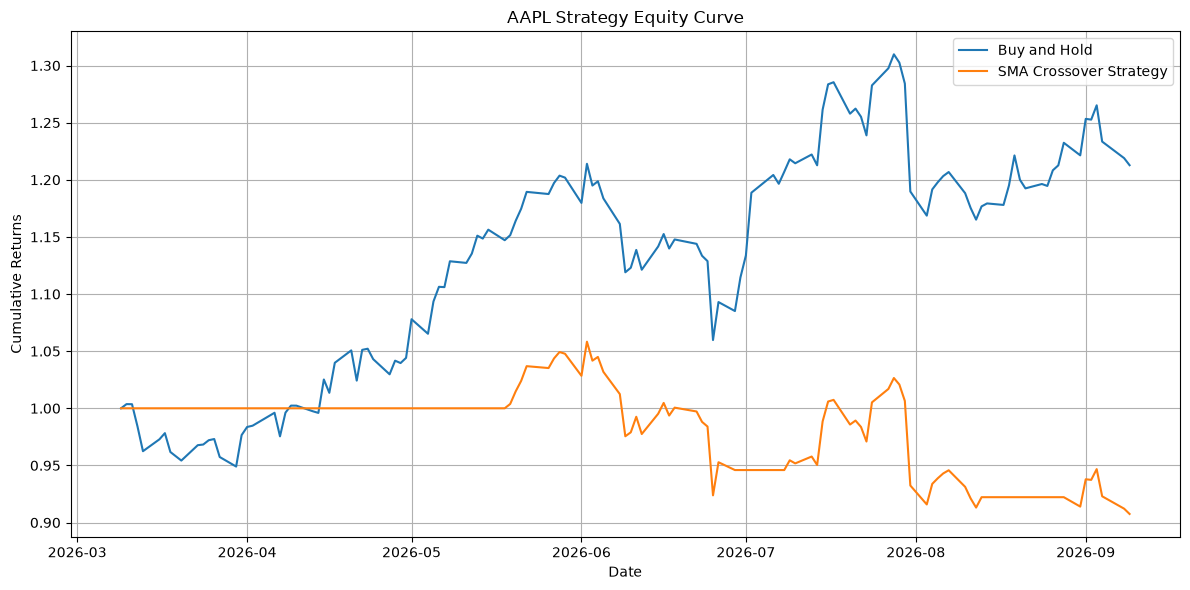

Saved strategy output to results/strategy_output/AAPL_sma_crossover.csv
Total trade events: 5

                     action       Close      SMA_10      SMA_50
Date                                                           
2026-05-18  ENTER (go long)  297.583344  293.149100  266.553968
2026-06-29   EXIT (go flat)  281.497223  291.216840  291.531868
2026-07-08  ENTER (go long)  313.119965  296.027692  295.597716
2026-08-13   EXIT (go flat)  305.260010  307.752866  309.031934
2026-08-28  ENTER (go long)  319.700012  312.106998  311.811248

Round-trip trades:
  2026-05-18 -> 2026-06-29: 297.58 -> 281.50  (-5.41%)
  2026-07-08 -> 2026-08-13: 313.12 -> 305.26  (-2.51%)
  2026-08-28 -> still open at end of data (Close: 319.70)


In [2]:
# In[1]: Import libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path

# In[2]: Load processed indicator data for a ticker
ticker = 'AAPL'
data_path = Path(f'data/processed/indicators/{ticker}_indicators.csv')
df = pd.read_csv(data_path, index_col=0, parse_dates=True)
df.index.name = 'Date'

assert {'SMA_10', 'SMA_50', 'Close'}.issubset(df.columns), (
    f"Missing expected columns in {data_path}. Found: {df.columns.tolist()}"
)

# In[3]: Generate SMA crossover signals (short=10, long=50)
df['signal'] = (df['SMA_10'] > df['SMA_50']).astype(int)
df['position'] = df['signal'].diff().fillna(0)
df['returns'] = df['Close'].pct_change().fillna(0)
df['strategy_returns'] = df['signal'].shift(1).fillna(0) * df['returns']

# In[5]: Compute cumulative returns
df['cum_returns'] = (1 + df['returns']).cumprod()
df['cum_strategy_returns'] = (1 + df['strategy_returns']).cumprod()

# In[6]: Quick performance summary
total_return_bh = df['cum_returns'].iloc[-1] - 1
total_return_strategy = df['cum_strategy_returns'].iloc[-1] - 1
n_trades = int((df['position'] != 0).sum())

print(f"{ticker} — Buy & Hold total return:    {total_return_bh:.2%}")
print(f"{ticker} — SMA Crossover total return: {total_return_strategy:.2%}")
print(f"Number of trades (entries + exits):     {n_trades}")

# In[7]: Plot equity curves
plt.figure(figsize=(12, 6))
plt.plot(df['cum_returns'], label='Buy and Hold')
plt.plot(df['cum_strategy_returns'], label='SMA Crossover Strategy')
plt.title(f'{ticker} Strategy Equity Curve')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.tight_layout()

os.makedirs('results/figures', exist_ok=True)
plt.savefig(f'results/figures/{ticker}_sma_crossover_equity_curve.png', dpi=150)
plt.show()

# In[8]: Save results for later reference (backtesting, reporting)
os.makedirs('results/strategy_output', exist_ok=True)
output_cols = ['Close', 'SMA_10', 'SMA_50', 'signal', 'position', 'returns',
               'strategy_returns', 'cum_returns', 'cum_strategy_returns']
df[output_cols].to_csv(f'results/strategy_output/{ticker}_sma_crossover.csv')
print(f"Saved strategy output to results/strategy_output/{ticker}_sma_crossover.csv")

# In[9]: Show individual entry/exit events
trades = df[df['position'] != 0][['Close', 'SMA_10', 'SMA_50', 'signal', 'position']].copy()
trades['action'] = trades['position'].map({1: 'ENTER (go long)', -1: 'EXIT (go flat)'})
trades['action'] = trades['action'].fillna(trades['position'].map(lambda x: f'other ({x})'))

print(f"Total trade events: {len(trades)}\n")
print(trades[['action', 'Close', 'SMA_10', 'SMA_50']].to_string())

# Round-trip summary: pair each ENTER with the following EXIT
entries = trades[trades['position'] == 1].index.tolist()
exits = trades[trades['position'] == -1].index.tolist()

print("\nRound-trip trades:")
for i, entry_date in enumerate(entries):
    exit_date = exits[i] if i < len(exits) else None
    if exit_date:
        entry_price = float(df.loc[entry_date, 'Close'])  # type: ignore[arg-type]
        exit_price = float(df.loc[exit_date, 'Close'])  # type: ignore[arg-type]
        trade_return = (exit_price / entry_price) - 1
        print(f"  {entry_date.date()} -> {exit_date.date()}: "
              f"{entry_price:.2f} -> {exit_price:.2f}  ({trade_return:+.2%})")
    else:
        close_val = float(df.loc[entry_date, 'Close'])  # type: ignore[arg-type]
        print(f"  {entry_date.date()} -> still open at end of data "
              f"(Close: {close_val:.2f})")